In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.metrics import R2Score

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [4]:
data=pd.read_csv('Admission_Predict.csv')

In [6]:
data.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [11]:
data.drop(columns='Serial No.', inplace=True)

In [12]:
data

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [28]:
X=data.drop(columns=['Chance of Admit '])
y=data['Chance of Admit ']

In [29]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train.shape, X_test.shape

((320, 7), (80, 7))

In [22]:
std=StandardScaler()

In [30]:
X_train_df=std.fit_transform(X_train[['GRE Score', 'TOEFL Score']])
X_test_df=std.fit_transform(X_test[['GRE Score', 'TOEFL Score']])

In [45]:
X_train_scaled = pd.DataFrame(X_train_df, columns=['GRE Score', 'TOEFL Score'], index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_df, columns=['GRE Score', 'TOEFL Score'], index=X_test.index)

X_train[['GRE Score', 'TOEFL Score']] = X_train_scaled
X_test[['GRE Score', 'TOEFL Score']] = X_test_scaled

In [46]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
3,0.457111,0.424662,3,3.5,2.5,8.67,1
18,0.102289,0.424662,3,4.0,3.0,8.80,0
202,2.053813,2.085930,5,4.5,4.5,9.91,1
250,0.279700,-0.572099,3,3.0,2.5,8.57,1
274,-0.163828,-1.236607,1,2.0,2.5,7.95,0
...,...,...,...,...,...,...,...
71,1.698990,0.756915,5,5.0,5.0,9.76,1
106,1.078051,0.590789,4,4.5,4.5,9.18,1
270,-0.962179,-0.405973,2,2.5,3.0,8.22,1
348,-1.317002,-1.402734,1,2.0,2.0,7.25,0


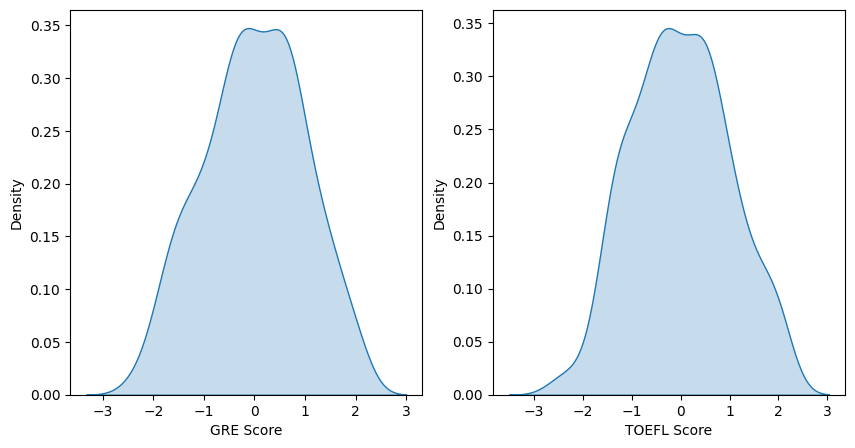

In [47]:
fig, ax=plt.subplots(1, 2, figsize=(10, 5))

sns.kdeplot(X_train['GRE Score'],fill=True, ax=ax[0])
sns.kdeplot(X_train['TOEFL Score'],fill=True, ax=ax[1])
plt.show()

In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
lr=LinearRegression()

In [50]:
lr.fit(X_train, y_train)

# How come this is possible data has no nan columns but X_train has

LinearRegression()

In [51]:
y_pred=lr.predict(X_test)
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_absolute_error(y_test, y_pred)))
print("R2: ", r2_score(y_test, y_pred))

MAE:  0.04804235511541731
MSE:  0.004696372020745566
RMSE:  0.21918566357181601
R2:  0.8181347379112806


In [142]:
model=Sequential()

In [143]:
model.add(Dense(20, activation='relu', input_dim=7))
model.add(Dense(10, activation='relu'))
model.add(Dense(5, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [144]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 20)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431 (1.68 KB)

 Trainable params: 431 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=[R2Score()])

In [146]:
history=model.fit(X_train, y_train, validation_split=0.2, epochs=100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0589 - r2_score: -2.2418 - val_loss: 0.0195 - val_r2_score: 0.0915
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0235 - r2_score: -0.2955 - val_loss: 0.0164 - val_r2_score: 0.2374
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0201 - r2_score: -0.1051 - val_loss: 0.0148 - val_r2_score: 0.3118
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0164 - r2_score: 0.0970 - val_loss: 0.0118 - val_r2_score: 0.4498
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0134 - r2_score: 0.2598 - val_loss: 0.0093 - val_r2_score: 0.5656
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0115 - r2_score: 0.3675 - val_loss: 0.0084 - val_r2_score: 0.6103
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0101 - r2_score: 0.4462 - val_loss: 0.0072 - val_r2_score: 0.6636
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0091 - r2_score: 0.5001 - val_loss: 0.0059 - val_r2_sco

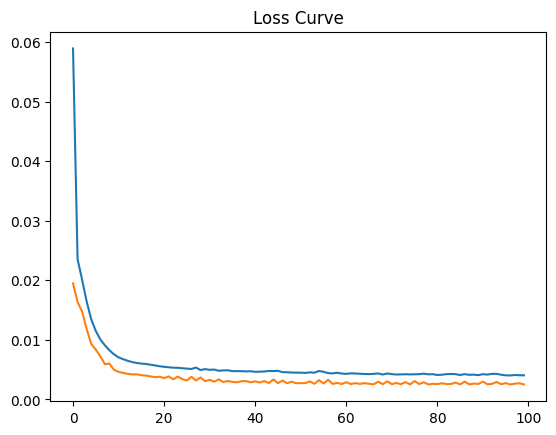

In [147]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.show()

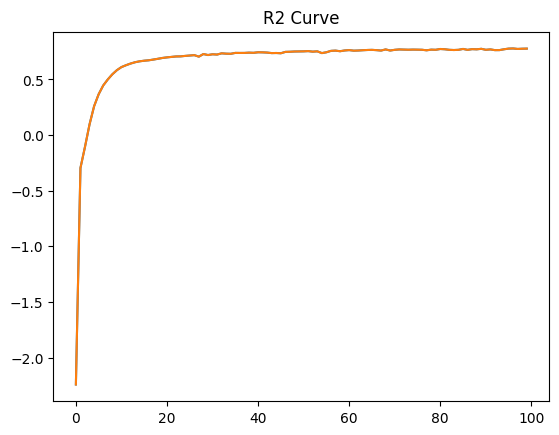

In [148]:
plt.plot(history.history['r2_score'])
plt.plot(history.history['r2_score'])
plt.title("R2 Curve")
plt.show()

In [149]:
y_pred=model.predict(X_test)
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_absolute_error(y_test, y_pred)))
print("R2: ", r2_score(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
MAE:  0.05267048576474189
MSE:  0.005601268416461338
RMSE:  0.22950051364810034
R2:  0.7830929611007926
